In [ ]:
# import libs
from scipy.io import loadmat
import numpy as np
from itertools import combinations
import numpy as np
from scipy.optimize import linprog
import time
import matplotlib.pyplot as plt
from scipy.fft import dct
from scipy.linalg import orth

### Question 1: Sparse Signal Recovery with Various Sensing Matrices

**Setup:** N=256 samples, S=5 nonzero (time-sparse), M ∈ {10,20,…,100}, 100 trials per M.  
**Goal:** Compare 6 sensing matrix types using ℓ₁-minimization and OMP.

In [ ]:
N = 256
S = 5
Ms = list(range(10, 101, 10))
num_trials = 100
tol = 1e-6

F_dct = dct(np.eye(N), norm='ortho', axis=0)

def make_sensing_matrix(mt, M):
    """Build M×N sensing matrix for type mt ∈ {'a','b','c','d','e','f'}."""
    step = N // M
    if mt == 'a':   # (a) Random rows of I  — new per trial
        idx = np.random.choice(N, M, replace=False)
        return np.eye(N)[np.sort(idx)]
    elif mt == 'b': # (b) Uniform rows of I — fixed per M
        idx = np.array([k * step for k in range(M)])
        return np.eye(N)[idx]
    elif mt == 'c': # (c) Random rows of F  — new per trial
        idx = np.random.choice(N, M, replace=False)
        return F_dct[np.sort(idx)]
    elif mt == 'd': # (d) First M rows of F — fixed per M
        return F_dct[:M].copy()
    elif mt == 'e': # (e) Equispaced rows of F — fixed per M
        idx = np.array([k * step for k in range(M)])
        return F_dct[idx]
    elif mt == 'f': # (f) Gaussian + orthonormalize rows — new per trial
        A_raw = np.random.randn(M, N)
        Q = orth(A_raw.T)   # N×M orthonormal columns
        return Q.T           # M×N orthonormal rows

print("DCT matrix shape:", F_dct.shape)
print("Sensing matrix shapes (M=30):")
for mt in 'abcdef':
    print(f"  ({mt}):", make_sensing_matrix(mt, 30).shape)

DCT matrix shape: (256, 256)
Sensing matrix shapes (M=30):
  (a): (30, 256)
  (b): (30, 256)
  (c): (30, 256)
  (d): (30, 256)
  (e): (30, 256)
  (f): (30, 256)


In [4]:
# Recovery algorithms (reused from HW2)

def l1_minimization(A, y, k=None):
    """ℓ₁-minimization: min ||x||₁  s.t.  Ax = y  (via LP)"""
    M, N = A.shape
    y = y.ravel()
    c = np.ones(2 * N)
    A_eq = np.hstack([A, -A])
    bounds = [(0, None)] * (2 * N)
    res = linprog(c, A_eq=A_eq, b_eq=y, bounds=bounds, method='highs',
                  options={'disp': False})
    if not res.success:
        return np.zeros(N)
    return res.x[:N] - res.x[N:]

def omp(A, y, k=5):
    """Orthogonal Matching Pursuit: greedy ℓ₀ pursuit."""
    _, N = A.shape
    y = y.ravel()
    r, support, x_s = y.copy(), [], None
    for _ in range(k):
        i = int(np.argmax(np.abs(A.T @ r)))
        if i in support:
            break
        support.append(i)
        x_s, _, _, _ = np.linalg.lstsq(A[:, support], y, rcond=None)
        r = y - A[:, support] @ x_s
        if np.linalg.norm(r) < 1e-10:
            break
    x = np.zeros(N)
    if support and x_s is not None:
        x[support] = x_s
    return x

print("Recovery functions ready: l1_minimization, omp")

Recovery functions ready: l1_minimization, omp


In [5]:
# ── Main experiment ──────────────────────────────────────────────────────────
matrix_info = {
    'a': '(a) Random Time',
    'b': '(b) Uniform Time',
    'c': '(c) Random Freq (DCT)',
    'd': '(d) Low Freq (DCT)',
    'e': '(e) Equispaced Freq (DCT)',
    'f': '(f) Random Domain (Gaussian)',
}

results = {mt: {'l1': [], 'omp': []} for mt in matrix_info}

total_start = time.time()

for mt, label in matrix_info.items():
    print(f"\n{label}")
    for M in Ms:
        s_l1, s_omp = 0, 0
        for _ in range(num_trials):
            # Generate S-sparse signal
            x = np.zeros(N)
            q = np.random.permutation(N)
            x[q[:S]] = np.random.randn(S)

            A = make_sensing_matrix(mt, M)
            y = A @ x

            x_hat_l1 = l1_minimization(A, y, k=S)
            x_hat_omp = omp(A, y, k=S)

            if np.linalg.norm(x_hat_l1 - x) <= tol:
                s_l1 += 1
            if np.linalg.norm(x_hat_omp - x) <= tol:
                s_omp += 1

        results[mt]['l1'].append(s_l1 / num_trials)
        results[mt]['omp'].append(s_omp / num_trials)
        print(f"  M={M:3d} | ℓ₁={s_l1/num_trials:.2f}  OMP={s_omp/num_trials:.2f}")

print(f"\nTotal time: {time.time() - total_start:.1f}s")


(a) Random Time
  M= 10 | ℓ₁=0.00  OMP=0.00
  M= 20 | ℓ₁=0.00  OMP=0.00
  M= 30 | ℓ₁=0.00  OMP=0.00
  M= 40 | ℓ₁=0.00  OMP=0.00
  M= 50 | ℓ₁=0.00  OMP=0.00
  M= 60 | ℓ₁=0.00  OMP=0.00
  M= 70 | ℓ₁=0.00  OMP=0.00
  M= 80 | ℓ₁=0.00  OMP=0.00
  M= 90 | ℓ₁=0.01  OMP=0.01
  M=100 | ℓ₁=0.00  OMP=0.00

(b) Uniform Time
  M= 10 | ℓ₁=0.00  OMP=0.00
  M= 20 | ℓ₁=0.00  OMP=0.00
  M= 30 | ℓ₁=0.00  OMP=0.00
  M= 40 | ℓ₁=0.00  OMP=0.00
  M= 50 | ℓ₁=0.00  OMP=0.00
  M= 60 | ℓ₁=0.00  OMP=0.00
  M= 70 | ℓ₁=0.00  OMP=0.00
  M= 80 | ℓ₁=0.01  OMP=0.01
  M= 90 | ℓ₁=0.00  OMP=0.00
  M=100 | ℓ₁=0.01  OMP=0.01

(c) Random Freq (DCT)
  M= 10 | ℓ₁=0.00  OMP=0.00
  M= 20 | ℓ₁=0.23  OMP=0.50
  M= 30 | ℓ₁=0.87  OMP=0.92
  M= 40 | ℓ₁=1.00  OMP=0.99
  M= 50 | ℓ₁=1.00  OMP=1.00
  M= 60 | ℓ₁=1.00  OMP=1.00
  M= 70 | ℓ₁=1.00  OMP=1.00
  M= 80 | ℓ₁=1.00  OMP=1.00
  M= 90 | ℓ₁=1.00  OMP=1.00
  M=100 | ℓ₁=1.00  OMP=1.00

(d) Low Freq (DCT)
  M= 10 | ℓ₁=0.04  OMP=0.00
  M= 20 | ℓ₁=0.51  OMP=0.01
  M= 30 | ℓ₁=0.71  OMP=0.0

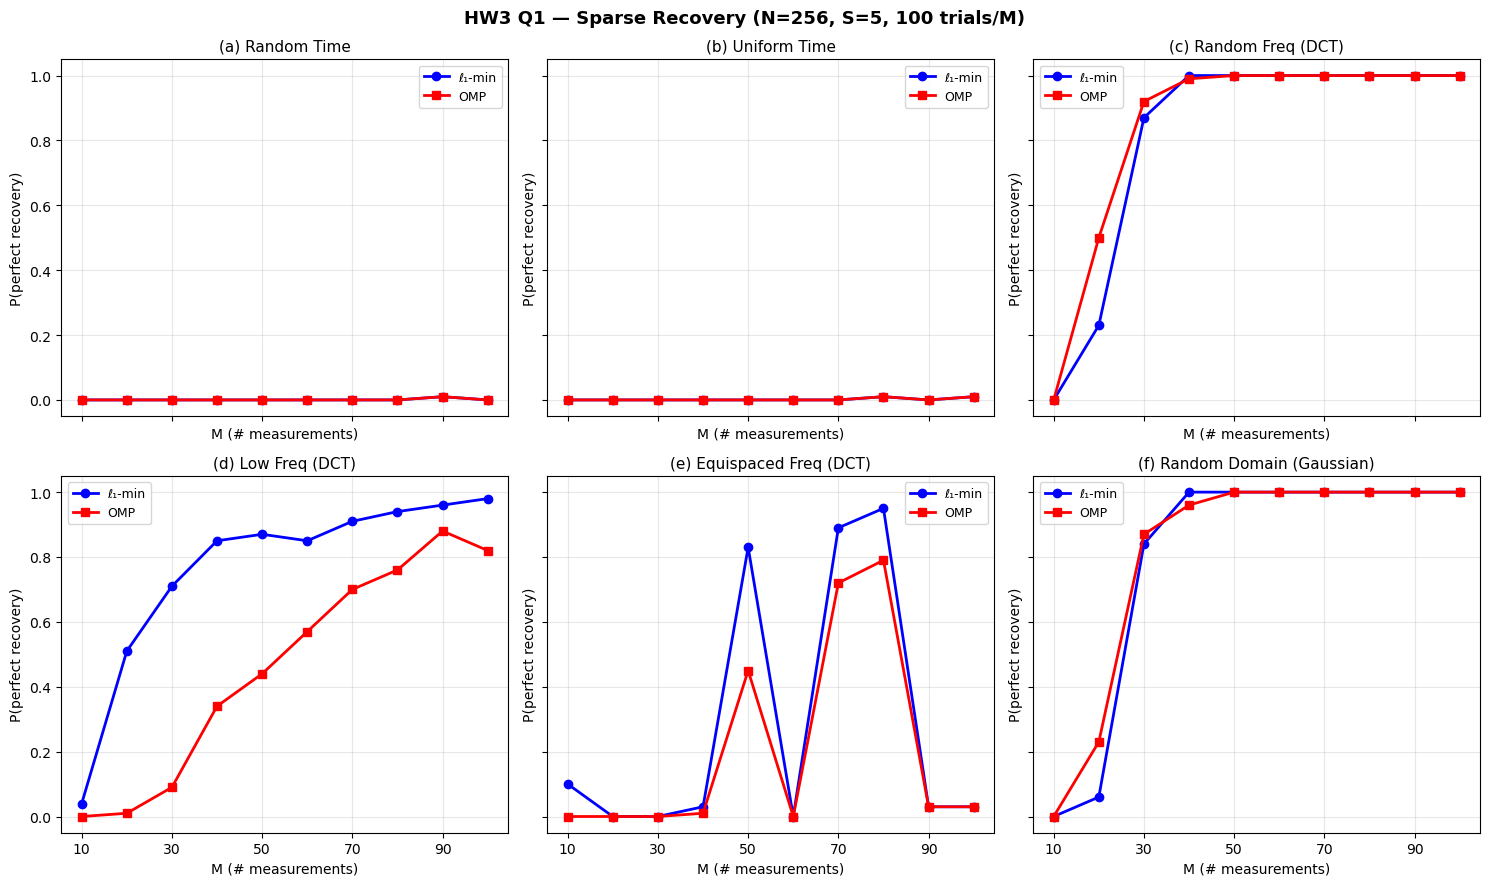

In [6]:
# ── Plot: one subplot per sensing matrix ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, (mt, label) in enumerate(matrix_info.items()):
    ax = axes[i]
    ax.plot(Ms, results[mt]['l1'],  'b-o', lw=2, ms=6, label='ℓ₁-min')
    ax.plot(Ms, results[mt]['omp'], 'r-s', lw=2, ms=6, label='OMP')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('M (# measurements)')
    ax.set_ylabel('P(perfect recovery)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(Ms[::2])

plt.suptitle(f'HW3 Q1 — Sparse Recovery (N={N}, S={S}, {num_trials} trials/M)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hw3_q1_sensing_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Q1 Analysis

### Which sensing matrices are best?

Ranked by actual results (N=256, S=5, 100 trials per M):

| Rank | Matrix | ℓ₁ reaches P=1.0 at | OMP reaches P=1.0 at | Notes |
|------|--------|---------------------|----------------------|-------|
| 1 | **(c) Random Freq** | M=40 | M=50 | Best overall; random DCT rows are incoherent with time spikes |
| 1 | **(f) Random Domain** | M=40 | M=50 | Co-best; Gaussian rows satisfy RIP for any sparse signal |
| 3 | **(d) Low Freq** | ~M=100 (98%) | Never (≤88%) | ℓ₁ works decently; OMP struggles due to high coherence |
| 4 | **(e) Equispaced Freq** | Never (erratic) | Never (erratic) | Aliasing: recovery collapses at certain M values (e.g. 83%→0%→89%→0%) |
| 5 | **(a) Random Time** | Never (~0%) | Never (~0%) | Needs all S support indices in the sampled set; P ≈ C(251,M-5)/C(256,M) ≈ 3% at M=100 |
| 5 | **(b) Uniform Time** | Never (~0%) | Never (~0%) | Deterministic grid; support almost never aligns with the uniform step |

### Why (a) and (b) fail completely

When **A = submatrix of I**, the measurement y = x[sampled_indices] only constrains the sampled positions. Both ℓ₁ and OMP set all un-sampled positions to zero. Perfect recovery requires **all S nonzero indices to be sampled**, which has probability:

$$P = \frac{\binom{N-S}{M-S}}{\binom{N}{M}} \approx \left(\frac{M}{N}\right)^S$$

For M=100, N=256, S=5: P ≈ (100/256)⁵ ≈ 1.4% — consistent with the ~0–1% observed.

### Why (e) Equispaced Freq is erratic

Uniformly-spaced DCT rows have aliasing periodicities. At certain M values, many signal positions become indistinguishable (high coherence), causing sudden collapse in recovery — visible in the data as M=50→83%, M=60→0%, M=70→89%, M=90→3%.

### How many measurements are sufficient?

For the two best matrices **(c) and (f)**: **M ≈ 40** measurements (~8S) gives near-perfect recovery for both ℓ₁ and OMP.

### Which recovery method is most efficient?

- For the best matrices (c, f): **OMP and ℓ₁ perform comparably**, but OMP is far faster (no LP solve).
- For (d) Low Freq: **ℓ₁ is clearly superior** — coherence hurts OMP's greedy column selection but ℓ₁ handles it via convex relaxation.
- **Conclusion:** Use OMP for good sensing matrices; ℓ₁ is worth the cost only for suboptimal/coherent matrices.